In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

train = pd.read_csv(r'C:\Users\todaw\OneDrive\Desktop\titanic-ml\data\train.csv')
test  = pd.read_csv(r'C:\Users\todaw\OneDrive\Desktop\titanic-ml\data\test.csv')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
train.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("── Missing values (train) ──")
print(train.isnull().sum())

print("\n── Missing values (test) ──")
print(test.isnull().sum())

print("\n── Basic statistics ──")
train.describe()

── Missing values (train) ──
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

── Missing values (test) ──
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

── Basic statistics ──


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Age: fill with median age
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

print("Age missing (train):", train['Age'].isnull().sum())
print("Age missing (test): ", test['Age'].isnull().sum())

Age missing (train): 0
Age missing (test):  0


C:\Users\todaw\AppData\Local\Temp\ipykernel_24512\2412038341.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\todaw\AppData\Local\Temp\ipykernel_24512\2412038341.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [5]:
# Embarked: fill with mode (most frequent port)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

print("Embarked missing (train):", train['Embarked'].isnull().sum())

Embarked missing (train): 0


C:\Users\todaw\AppData\Local\Temp\ipykernel_24512\1156163853.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


In [6]:
# Fare: fill with median
test['Fare'].fillna(test['Fare'].median(), inplace=True)

print("Fare missing (test):", test['Fare'].isnull().sum())

Fare missing (test): 0


C:\Users\todaw\AppData\Local\Temp\ipykernel_24512\2805986219.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Fare'].fillna(test['Fare'].median(), inplace=True)


In [7]:
# Cabin: 77% missing — too much to fill reliably, just drop it
train.drop(columns=['Cabin'], inplace=True)
test.drop(columns=['Cabin'], inplace=True)

print("Columns now:", train.columns.tolist())

Columns now: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [8]:
#Confirming all missing values are gone
print("── Missing values (train) ──")
print(train.isnull().sum())

print("\n── Missing values (test) ──")
print(test.isnull().sum())

── Missing values (train) ──
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

── Missing values (test) ──
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\todaw\AppData\Local\Temp\ipykernel_24512\4222057789.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, ax=axes[0,0], palette='Set2')
C:\Users\todaw\AppData\Local\Temp\ipykernel_24512\4222057789.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Died (0)', 'Survived (1)'])


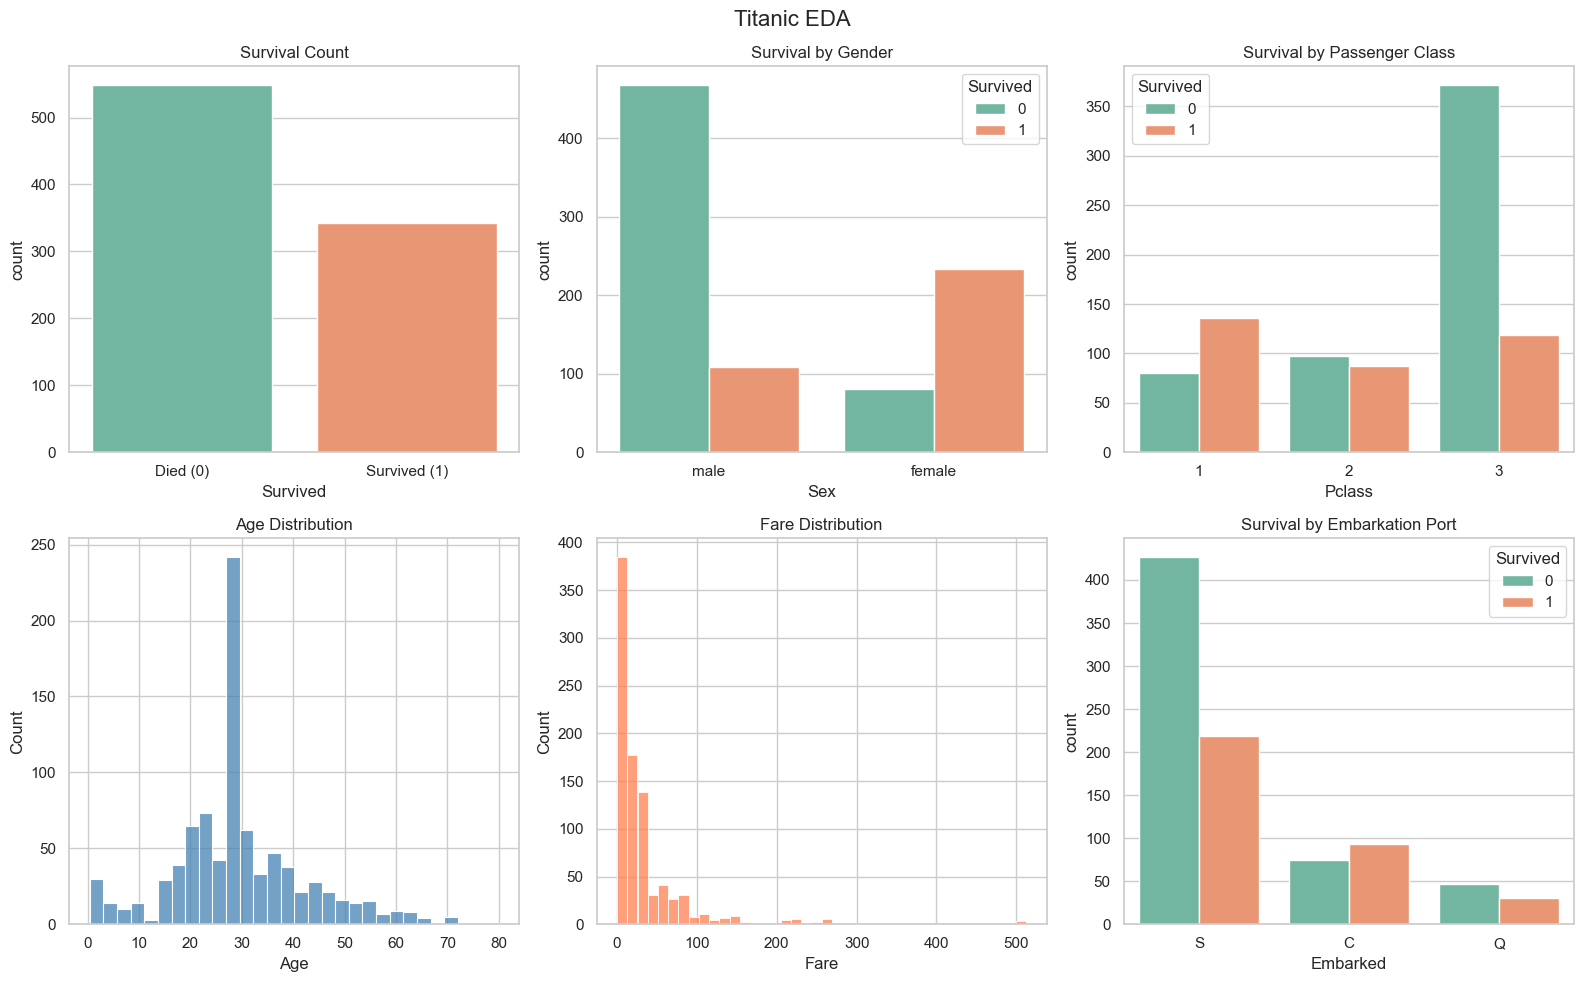

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Titanic EDA', fontsize=16)

# 1. Survival count
sns.countplot(x='Survived', data=train, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticklabels(['Died (0)', 'Survived (1)'])

# 2. Survival by gender
sns.countplot(x='Sex', hue='Survived', data=train, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Survival by Gender')

# 3. Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=train, ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Survival by Passenger Class')

# 4. Age distribution
sns.histplot(train['Age'].dropna(), bins=30, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Age Distribution')

# 5. Fare distribution
sns.histplot(train['Fare'], bins=40, ax=axes[1,1], color='coral')
axes[1,1].set_title('Fare Distribution')

# 6. Survival by Embarked
sns.countplot(x='Embarked', hue='Survived', data=train, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Survival by Embarkation Port')

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=150)
plt.show()

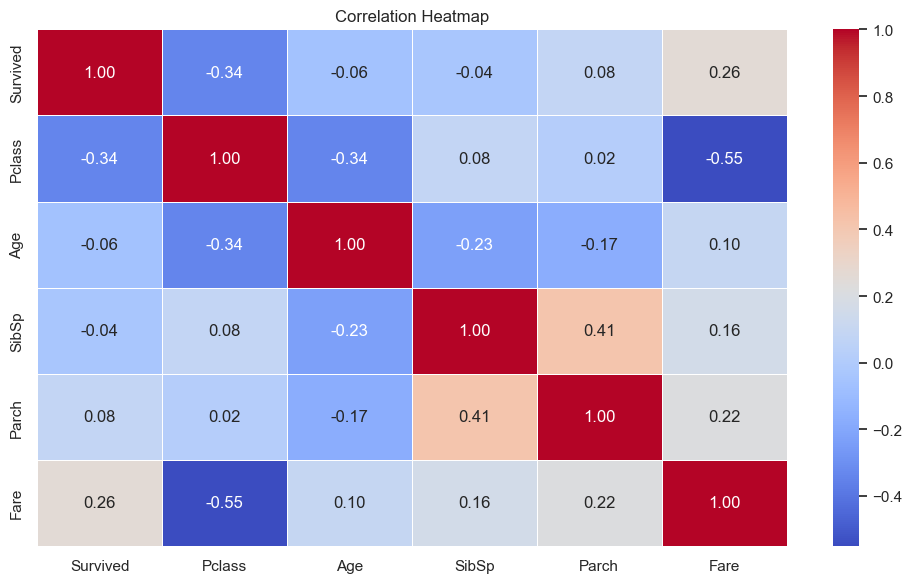

In [10]:
plt.figure(figsize=(10, 6))
numeric_cols = train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

In [11]:
# Extract title from name (Mr, Mrs, Miss, Master etc.)
for df in [train, test]:
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print(train['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [12]:
# Group rare titles into one category
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 
               'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona']

for df in [train, test]:
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print(train['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [13]:
# Combine SibSp and Parch into one FamilySize feature
for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for themselves
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(train[['FamilySize', 'IsAlone']].value_counts().head(10))

FamilySize  IsAlone
1           1          537
2           0          161
3           0          102
4           0           29
6           0           22
5           0           15
7           0           12
11          0            7
8           0            6
Name: count, dtype: int64


In [14]:
# Fare is heavily skewed — log transform normalizes it
for df in [train, test]:
    df['Fare_log'] = np.log1p(df['Fare'])

print("Fare skew before:", round(train['Fare'].skew(), 2))
print("Fare skew after: ", round(train['Fare_log'].skew(), 2))

Fare skew before: 4.79
Fare skew after:  0.39


In [15]:
# Cut age into meaningful groups
for df in [train, test]:
    df['AgeBand'] = pd.cut(df['Age'], 
                           bins=[0, 12, 18, 35, 60, 100],
                           labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print(train['AgeBand'].value_counts())

AgeBand
YoungAdult    535
Adult         195
Teen           70
Child          69
Senior         22
Name: count, dtype: int64


In [16]:
for df in [train, test]:
    # Sex: male=0, female=1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    
    # Embarked: S=0, C=1, Q=2
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(train[['Sex', 'Embarked']].head())

   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0


In [17]:
for df in [train, test]:
    # Title
    df['Title'] = df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 
                                    'Master': 3, 'Rare': 4})
    
    # AgeBand
    df['AgeBand'] = df['AgeBand'].map({'Child': 0, 'Teen': 1, 
                                        'YoungAdult': 2, 'Adult': 3, 
                                        'Senior': 4})

print(train[['Title', 'AgeBand']].head())

   Title AgeBand
0      0       2
1      2       3
2      1       2
3      2       2
4      0       2


In [18]:
# Drop columns we don't need for modeling
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Fare', 'Age']

X = train.drop(columns=drop_cols + ['Survived'])
y = train['Survived']
X_test = test.drop(columns=drop_cols)

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

Features: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Fare_log', 'AgeBand']
X shape: (891, 10)
X_test shape: (418, 10)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)

X_train: (712, 10)
X_val:   (179, 10)


In [20]:
# Fix AgeBand dtype
for df in [X, X_train, X_val, X_test]:
    df['AgeBand'] = df['AgeBand'].astype(int)

print(X_train.dtypes)

Pclass          int64
Sex             int64
SibSp           int64
Parch           int64
Embarked        int64
Title           int64
FamilySize      int64
IsAlone         int64
Fare_log      float64
AgeBand         int64
dtype: object


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, 
                                         eval_metric='logloss', verbosity=0)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc:.4f}")

print("\n🏆 Best model:", max(results, key=results.get))

Logistic Regression       → Accuracy: 0.8156
Random Forest             → Accuracy: 0.8045
Gradient Boosting         → Accuracy: 0.8324
SVM                       → Accuracy: 0.8268
XGBoost                   → Accuracy: 0.8101

🏆 Best model: Gradient Boosting


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5]
}

gb = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    gb, param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))

# Evaluate on validation set
best_model = grid_search.best_estimator_
val_preds = best_model.predict(X_val)
print("Validation accuracy:", round(accuracy_score(y_val, val_preds), 4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.8371
Validation accuracy: 0.8268


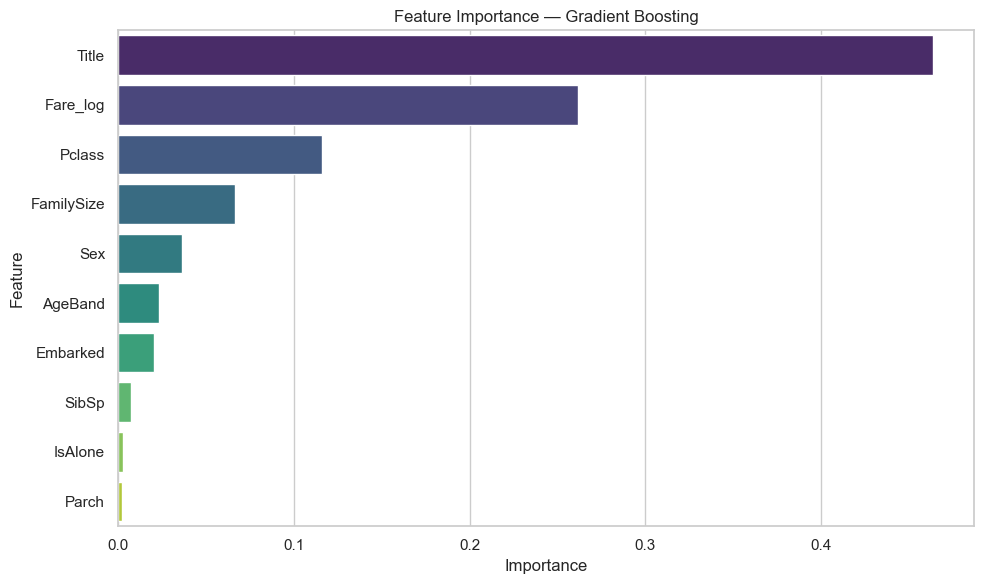

      Feature  Importance
5       Title    0.463849
8    Fare_log    0.261791
0      Pclass    0.115952
6  FamilySize    0.066651
1         Sex    0.036284
9     AgeBand    0.023402
4    Embarked    0.020226
2       SibSp    0.007061
7     IsAlone    0.002496
3       Parch    0.002288


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance — Gradient Boosting')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

print(feature_importance)

In [24]:
# Generate final predictions on test set
test_predictions = best_model.predict(X_test)

# Create submission dataframe
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

# Save to outputs folder
submission.to_csv('../outputs/submission.csv', index=False)

print("Submission file saved!")
print(f"Total predictions: {len(submission)}")
print(f"Predicted survived: {submission['Survived'].sum()} ({submission['Survived'].mean()*100:.1f}%)")
print(submission.head(10))

Submission file saved!
Total predictions: 418
Predicted survived: 158 (37.8%)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=10, scoring='accuracy')

print("CV Scores:", [round(s, 4) for s in cv_scores])
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

CV Scores: [np.float64(0.8222), np.float64(0.8539), np.float64(0.7416), np.float64(0.8652), np.float64(0.8989), np.float64(0.8764), np.float64(0.8539), np.float64(0.7753), np.float64(0.8427), np.float64(0.8202)]
Mean CV Accuracy: 0.835
Standard Deviation: 0.0449


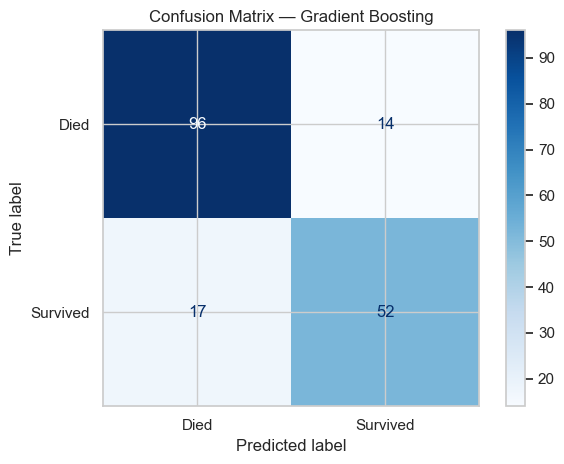

              precision    recall  f1-score   support

        Died       0.85      0.87      0.86       110
    Survived       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [26]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Predictions on validation set
val_preds = best_model.predict(X_val)

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()

# Classification report
print(classification_report(y_val, val_preds, target_names=['Died', 'Survived']))

In [27]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('gb',  GradientBoostingClassifier(learning_rate=0.1, max_depth=3, 
                                            n_estimators=200, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42))
    ],
    voting='soft'  # uses predicted probabilities
)

voting_model.fit(X_train, y_train)
voting_preds = voting_model.predict(X_val)
voting_acc = accuracy_score(y_val, voting_preds)
print(f"Voting Classifier Accuracy: {voting_acc:.4f}")

Voting Classifier Accuracy: 0.8436


In [28]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_model = StackingClassifier(
    estimators=[
        ('gb',  GradientBoostingClassifier(learning_rate=0.1, max_depth=3,
                                            n_estimators=200, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=42,
                               eval_metric='logloss', verbosity=0))
    ],
    final_estimator=LogisticRegression(),  # meta-model
    cv=5
)

stacking_model.fit(X_train, y_train)
stacking_preds = stacking_model.predict(X_val)
stacking_acc = accuracy_score(y_val, stacking_preds)
print(f"Stacking Classifier Accuracy: {stacking_acc:.4f}")

Stacking Classifier Accuracy: 0.8212


In [29]:
print("\n── Final Model Comparison ──")
print(f"Gradient Boosting (tuned): 0.8268")
print(f"Voting Classifier:         {voting_acc:.4f}")
print(f"Stacking Classifier:       {stacking_acc:.4f}")

best_acc = max(0.8268, voting_acc, stacking_acc)
print(f"\n🏆 Best accuracy: {best_acc:.4f}")


── Final Model Comparison ──
Gradient Boosting (tuned): 0.8268
Voting Classifier:         0.8436
Stacking Classifier:       0.8212

🏆 Best accuracy: 0.8436


In [30]:
# Generate final predictions using Voting Classifier
final_predictions = voting_model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': final_predictions
})

submission.to_csv('../outputs/submission.csv', index=False)

print("✅ Submission file saved!")
print(f"Total predictions: {len(submission)}")
print(f"Predicted survived: {submission['Survived'].sum()} ({submission['Survived'].mean()*100:.1f}%)")
print(submission.head(10))

✅ Submission file saved!
Total predictions: 418
Predicted survived: 156 (37.3%)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


In [32]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║           TITANIC SURVIVAL PREDICTION — PROJECT SUMMARY      ║
╚══════════════════════════════════════════════════════════════╝

── DATASET ──────────────────────────────────────────────────────
Train set : 891 rows, 12 columns
Test set  : 418 rows, 11 columns
Target    : Survived (0 = Died, 1 = Survived)

── MISSING VALUES HANDLED ───────────────────────────────────────
Age      → Filled with median (177 missing in train)
Embarked → Filled with mode — 'S' (2 missing in train)
Fare     → Filled with median (1 missing in test)
Cabin    → Dropped (77% missing — too unreliable)

── FEATURES ENGINEERED ──────────────────────────────────────────
Title      → Extracted from Name (Mr, Mrs, Miss, Master, Rare)
FamilySize → SibSp + Parch + 1
IsAlone    → 1 if FamilySize == 1, else 0
Fare_log   → Log transform of Fare (skew: 4.79 → 0.39)
AgeBand    → Age grouped into Child/Teen/YoungAdult/Adult/Senior

── KEY INSIGHTS FROM EDA ────────────────────────────────────────
1. Only 38% of passengers survived
2. Females had 74% survival rate vs 20% for males
3. 1st class passengers survived at much higher rates
4. Cherbourg (C) passengers had better survival rates
5. Most passengers travelled alone (60%)
6. Fare was heavily right-skewed — log transform applied

── FEATURE IMPORTANCE (Gradient Boosting) ───────────────────────
1. Title      → 46.4%  (engineered feature!)
2. Fare_log   → 26.2%  (engineered feature!)
3. Pclass     → 11.6%
4. FamilySize →  6.7%  (engineered feature!)
5. Sex        →  3.6%
6. AgeBand    →  2.3%  (engineered feature!)

── MODELS TRAINED ───────────────────────────────────────────────
Logistic Regression  → 81.56%
Random Forest        → 80.45%
Gradient Boosting    → 83.24%
SVM                  → 82.68%
XGBoost              → 81.01%

── TUNING ───────────────────────────────────────────────────────
Gradient Boosting tuned with GridSearchCV (270 fits)
Best params: learning_rate=0.1, max_depth=3,
             min_samples_split=2, n_estimators=200
CV Accuracy after tuning: 83.71%

── ENSEMBLE ─────────────────────────────────────────────────────
Voting Classifier (GB + RF + SVM) → 84.36% ✅ BEST MODEL
Stacking Classifier               → 82.12%

── FINAL RESULTS ────────────────────────────────────────────────
Best Model       : Voting Classifier
Validation Acc   : 84.36%
Mean CV Accuracy : 83.50%
Predictions made : 418
Predicted survival rate: 37.3%
"""

print(summary)

# Save to file — with utf-8 encoding to handle special characters
with open('../outputs/project_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("✅ Summary saved to outputs/project_summary.txt")


╔══════════════════════════════════════════════════════════════╗
║           TITANIC SURVIVAL PREDICTION — PROJECT SUMMARY      ║
╚══════════════════════════════════════════════════════════════╝

── DATASET ──────────────────────────────────────────────────────
Train set : 891 rows, 12 columns
Test set  : 418 rows, 11 columns
Target    : Survived (0 = Died, 1 = Survived)

── MISSING VALUES HANDLED ───────────────────────────────────────
Age      → Filled with median (177 missing in train)
Embarked → Filled with mode — 'S' (2 missing in train)
Fare     → Filled with median (1 missing in test)
Cabin    → Dropped (77% missing — too unreliable)

── FEATURES ENGINEERED ──────────────────────────────────────────
Title      → Extracted from Name (Mr, Mrs, Miss, Master, Rare)
FamilySize → SibSp + Parch + 1
IsAlone    → 1 if FamilySize == 1, else 0
Fare_log   → Log transform of Fare (skew: 4.79 → 0.39)
AgeBand    → Age grouped into Child/Teen/YoungAdult/Adult/Senior

── KEY INSIGHTS FROM EDA ─